# Phase 4 — Evaluation, Calibration, Explainability, and Domain Adaptation

**Project:** Heart Disease ML — AI in Medicine  
**Goal:** evaluate the optimized Phase 3 models on the external Hungarian and Swiss splits while covering the four required pillars:

1. **Performance** — AUC-ROC, AUC-PR, F1, sensitivity, specificity.
2. **Explainability** — SHAP analysis, especially TreeExplainer for XGBoost.
3. **Calibration** — Platt/sigmoid and isotonic calibration with reliability diagrams and ECE.
4. **Domain adaptation** — ablation with and without CORAL target-to-source alignment.

This notebook is a **runner/report only**. It displays results inline and does not save output files. The later `src/04_evaluation.py` runner should save final tables and figures.

## Prompt

Think about the four evaluation pillars the professor asked for: performance, explainability, calibration, and domain adaptation.

Plan: for each model compute AUC-ROC, AUC-PR, F1, sensitivity, and specificity on Hungarian and Swiss; run a DeLong test between the top two models; generate SHAP summary plots for the best tree model; fit Platt scaling and isotonic regression on a Cleveland holdout and plot reliability diagrams with ECE scores; run an ablation comparing with vs. without domain adaptation to quantify its impact.

Check: the preprocessing pipeline from Phase 3 must be applied identically. Nothing is refitted on Hungarian or Swiss labels.

Execute: produce all metrics in a summary table, reliability diagrams, SHAP plots, and domain adaptation ablation results.

Evaluate: confirm whether calibration improves ECE, whether SHAP rankings align with clinical intuition, and whether domain adaptation gives a clean before/after delta for the final write-up.

## Important leakage policy

Hungarian and Swiss are used only as external evaluation sets. Their labels are never used for fitting preprocessors, models, calibrators, thresholds, or hyperparameters.

The only unsupervised use of external data allowed here is the domain-adaptation ablation, where CORAL uses unlabeled target-site feature distributions. This must be reported clearly as unsupervised test-time adaptation.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

In [2]:
# Optional dependencies
try:
    import shap
except ImportError:
    shap = None
    print("SHAP is not installed. Install with: pip install shap")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("XGBoost is not installed. Install with: pip install xgboost")

## Compatibility classes for loading Phase 3 models

Because the Phase 3 models contain custom pipeline classes, the same class names are defined here before loading the `.joblib` files. This makes model loading robust even when the models were saved from a script.

In [3]:
RAW_FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal"
]

class ClinicalFeatureEngineer(BaseEstimator, TransformerMixin):
    """Same feature engineering class used in Phase 3."""

    def __init__(self):
        self.feature_names_in_ = None
        self.feature_names_out_ = None

    def fit(self, X, y=None):
        X_df = self._to_dataframe(X)
        self.feature_names_in_ = list(X_df.columns)
        self.feature_names_out_ = list(self.transform(X_df).columns)
        return self

    def transform(self, X):
        X_df = self._to_dataframe(X).copy()
        for col in X_df.columns:
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

        X_df["age_x_thalach"] = X_df["age"] * X_df["thalach"]
        X_df["age_x_oldpeak"] = X_df["age"] * X_df["oldpeak"]
        X_df["trestbps_x_chol"] = X_df["trestbps"] * X_df["chol"]
        X_df["cp_x_thal"] = X_df["cp"] * X_df["thal"]
        X_df["exang_x_oldpeak"] = X_df["exang"] * X_df["oldpeak"]

        age_component = X_df["age"] / 10.0
        male_component = X_df["sex"] * 2.0
        chol_component = (X_df["chol"] - 200.0) / 40.0
        bp_component = (X_df["trestbps"] - 120.0) / 20.0
        fbs_component = X_df["fbs"] * 1.5
        X_df["framingham_proxy"] = age_component + male_component + chol_component + bp_component + fbs_component
        return X_df

    def get_feature_names_out(self, input_features=None):
        if self.feature_names_out_ is None:
            return np.array(input_features if input_features is not None else [])
        return np.array(self.feature_names_out_)

    @staticmethod
    def _to_dataframe(X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X, columns=RAW_FEATURES[: X.shape[1]])

class CORALTargetToSourceAdapter:
    """CORAL alignment that maps target-site processed features into source-space statistics."""

    def __init__(self, eps: float = 1e-5):
        self.eps = eps
        self.source_mean_ = None
        self.target_mean_ = None
        self.target_whiten_ = None
        self.source_recolor_ = None

    def fit(self, X_source, X_target):
        Xs = np.asarray(X_source, dtype=float)
        Xt = np.asarray(X_target, dtype=float)

        self.source_mean_ = Xs.mean(axis=0)
        self.target_mean_ = Xt.mean(axis=0)

        Cs = np.cov(Xs, rowvar=False) + self.eps * np.eye(Xs.shape[1])
        Ct = np.cov(Xt, rowvar=False) + self.eps * np.eye(Xt.shape[1])

        self.target_whiten_ = self._matrix_power(Ct, -0.5)
        self.source_recolor_ = self._matrix_power(Cs, 0.5)
        return self

    def transform(self, X_target):
        Xt = np.asarray(X_target, dtype=float)
        Xt_centered = Xt - self.target_mean_
        return Xt_centered @ self.target_whiten_ @ self.source_recolor_ + self.source_mean_

    @staticmethod
    def _matrix_power(matrix, power):
        eigvals, eigvecs = np.linalg.eigh(matrix)
        eigvals = np.maximum(eigvals, 1e-12)
        return eigvecs @ np.diag(eigvals ** power) @ eigvecs.T

## Load Phase 1 data and Phase 3 artifacts

This notebook expects:

- `src/01_dataset.py`
- `outputs/models/phase3_logistic_regression.joblib`
- `outputs/models/phase3_xgboost_optuna.joblib`
- `outputs/models/phase3_small_mlp.joblib`
- `outputs/tables/phase3_cv_summary.csv`
- `outputs/tables/phase3_best_params.json`
- `outputs/tables/phase3_feature_names.csv`

In [4]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUTS_DIR / "tables"
MODEL_DIR = OUTPUTS_DIR / "models"

PHASE1_PATH = SRC_DIR / "01_dataset.py"
assert PHASE1_PATH.exists(), f"Cannot find Phase 1 runner: {PHASE1_PATH}"

spec = importlib.util.spec_from_file_location("phase1_dataset", PHASE1_PATH)
phase1_dataset = importlib.util.module_from_spec(spec)
spec.loader.exec_module(phase1_dataset)

phase1_outputs = phase1_dataset.run_dataset_setup()
cleveland = phase1_outputs["cleveland"].copy()
hungarian = phase1_outputs["hungarian"].copy()
swiss = phase1_outputs["swiss"].copy()

X_cleveland = cleveland[RAW_FEATURES].copy()
y_cleveland = cleveland["target"].copy()

external_splits = {
    "Hungarian": (hungarian[RAW_FEATURES].copy(), hungarian["target"].copy()),
    "Swiss": (swiss[RAW_FEATURES].copy(), swiss["target"].copy()),
}

print("Loaded external splits:")
for name, (X_ext, y_ext) in external_splits.items():
    print(f"{name}: X={X_ext.shape}, positive_rate={y_ext.mean():.2%}")


Phase 1 — Dataset setup
Loading Cleveland, Hungarian, and Swiss UCI Heart Disease splits...
Found local file for cleveland: /Users/aexomir/Desktop/AIMed/data/raw/processed.cleveland.data
Found local file for hungarian: /Users/aexomir/Desktop/AIMed/data/raw/processed.hungarian.data
Found local file for swiss: /Users/aexomir/Desktop/AIMed/data/raw/processed.switzerland.data
Column alignment check passed for Cleveland, Hungarian, and Swiss.

CLEVELAND
Shape: 303 rows × 16 columns

Binary label distribution:
target
0    164
1    139
Positive disease rate: 45.87%

Original target values before binary collapse:
target_original
0    164
1     55
2     36
3     35
4     13

Missing values in modeling columns:
ca      4
thal    2

HUNGARIAN
Shape: 294 rows × 16 columns

Binary label distribution:
target
0    188
1    106
Positive disease rate: 36.05%

Original target values before binary collapse:
target_original
0    188
1    106

Missing values in modeling columns:
trestbps      1
chol      

In [5]:
phase3_cv_summary = pd.read_csv(TABLE_DIR / "phase3_cv_summary.csv")
phase3_feature_names = pd.read_csv(TABLE_DIR / "phase3_feature_names.csv")

with open(TABLE_DIR / "phase3_best_params.json", "r") as f:
    phase3_best_params = json.load(f)

models = {
    "Logistic Regression": joblib.load(MODEL_DIR / "phase3_logistic_regression.joblib"),
    "XGBoost + Optuna": joblib.load(MODEL_DIR / "phase3_xgboost_optuna.joblib"),
    "Small MLP": joblib.load(MODEL_DIR / "phase3_small_mlp.joblib"),
}

print("Phase 3 CV summary:")
display(phase3_cv_summary)
print("Loaded models:", list(models.keys()))
print("Engineered feature count:", len(phase3_feature_names))

Phase 3 CV summary:


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std
0,Logistic Regression,0.910893,0.021197,0.909500,0.034910,0.818143,0.046586,0.798413,0.066657,0.872348,0.039576
1,XGBoost + Optuna,0.910864,0.029515,0.907054,0.037162,0.813420,0.038919,0.776720,0.070110,0.890530,0.023485
2,Small MLP,0.908886,0.022636,0.910990,0.030918,0.799444,0.037434,0.805556,0.070541,0.823864,0.074632


Loaded models: ['Logistic Regression', 'XGBoost + Optuna', 'Small MLP']
Engineered feature count: 19


## Performance metrics on external sites

All three final Phase 3 models are evaluated on Hungarian and Swiss. The threshold-dependent metrics use the default probability threshold of 0.5. Later, the report should discuss that Swiss is extremely imbalanced, so specificity is unstable because there are very few negative cases.

In [6]:
def get_positive_proba(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2:
        return proba[:, 1]
    return proba


def specificity_score_binary(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "auc_pr": average_precision_score(y_true, y_score),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity_score_binary(y_true, y_pred),
        "n": len(y_true),
        "positive_rate": float(np.mean(y_true)),
    }

performance_rows = []
external_predictions = {}

for split_name, (X_ext, y_ext) in external_splits.items():
    external_predictions[split_name] = {}
    for model_name, model in models.items():
        y_score = get_positive_proba(model, X_ext)
        external_predictions[split_name][model_name] = y_score
        metrics = compute_metrics(y_ext, y_score)
        performance_rows.append({
            "split": split_name,
            "model": model_name,
            "adaptation": "none",
            **metrics,
        })

external_performance = pd.DataFrame(performance_rows)
external_performance.sort_values(["split", "auc_roc"], ascending=[True, False])

,split,model,adaptation,auc_roc,auc_pr,f1,sensitivity,specificity,n,positive_rate
1,Hungarian,XGBoost + Optuna,none,0.886617,0.845701,0.621951,0.481132,0.962766,294,0.360544
2,Hungarian,Small MLP,none,0.862605,0.813031,0.721649,0.660377,0.904255,294,0.360544
0,Hungarian,Logistic Regression,none,0.857035,0.820928,0.681564,0.575472,0.936170,294,0.360544
4,Swiss,XGBoost + Optuna,none,0.732065,0.974529,0.598802,0.434783,0.750000,123,0.934959
5,Swiss,Small MLP,none,0.704348,0.964569,0.728261,0.582609,0.750000,123,0.934959
3,Swiss,Logistic Regression,none,0.652174,0.957887,0.531646,0.365217,0.875000,123,0.934959


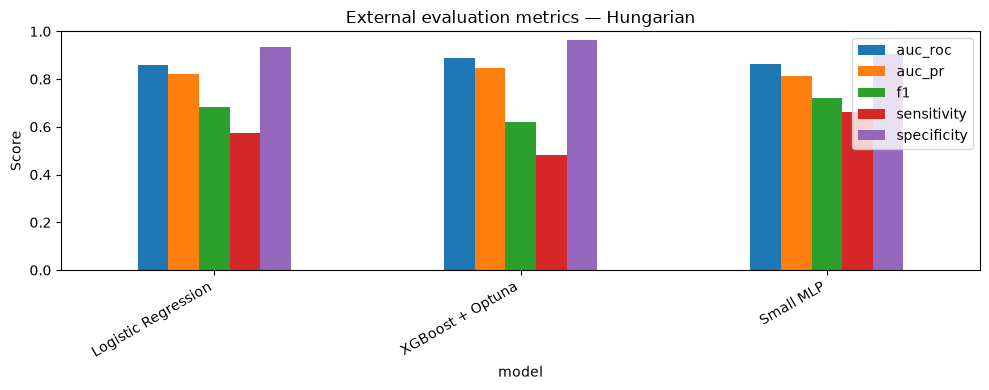

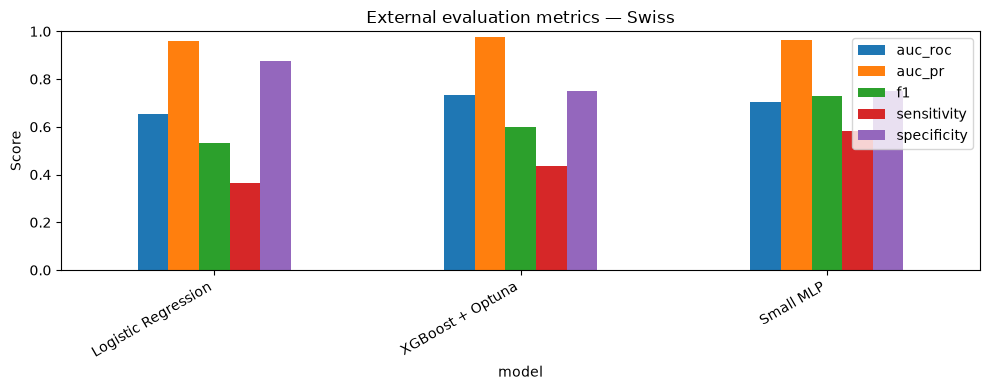

In [7]:
for split_name in external_splits:
    plot_df = external_performance[external_performance["split"] == split_name]
    ax = plot_df.set_index("model")[["auc_roc", "auc_pr", "f1", "sensitivity", "specificity"]].plot(kind="bar", figsize=(10, 4))
    ax.set_title(f"External evaluation metrics — {split_name}")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## DeLong test between top two models

The DeLong test compares correlated AUCs on the same patients. The top two models are selected separately for each external split based on AUC-ROC.

If the p-value is large, the apparent AUC difference is not statistically significant. This is especially likely with small external samples.

In [9]:
# Compact DeLong implementation for paired ROC-AUC comparison.
# Based on the standard fast DeLong covariance approach.

from scipy.stats import norm

def compute_midrank(x):
    x = np.asarray(x)
    order = np.argsort(x)
    sorted_x = x[order]
    n = len(x)
    midranks = np.zeros(n, dtype=float)
    i = 0
    while i < n:
        j = i
        while j < n and sorted_x[j] == sorted_x[i]:
            j += 1
        midranks[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    result = np.empty(n, dtype=float)
    result[order] = midranks
    return result


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delong_cov = sx / m + sy / n
    return aucs, delong_cov


def delong_roc_test(y_true, pred_one, pred_two):
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true)
    label_1_count = int(np.sum(y_true))
    preds = np.vstack([pred_one, pred_two])[:, order]
    aucs, cov = fast_delong(preds, label_1_count)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return aucs, diff, np.nan, np.nan
    z = abs(diff) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return aucs, diff, z, p


delong_rows = []
for split_name, (X_ext, y_ext) in external_splits.items():
    split_perf = external_performance[external_performance["split"] == split_name].sort_values("auc_roc", ascending=False)
    top_models = split_perf["model"].head(2).tolist()
    m1, m2 = top_models
    aucs, diff, z, p = delong_roc_test(
        y_ext,
        external_predictions[split_name][m1],
        external_predictions[split_name][m2],
    )
    delong_rows.append({
        "split": split_name,
        "model_1": m1,
        "model_2": m2,
        "auc_1": aucs[0],
        "auc_2": aucs[1],
        "auc_diff": diff,
        "z": z,
        "p_value": p,
    })

delong_results = pd.DataFrame(delong_rows)
delong_results

,split,model_1,model_2,auc_1,auc_2,auc_diff,z,p_value
0,Hungarian,XGBoost + Optuna,Small MLP,0.886617,0.862605,0.024011,1.853716,0.063780
1,Swiss,XGBoost + Optuna,Small MLP,0.732065,0.704348,0.027717,0.539593,0.589478


## Calibration: Platt scaling and isotonic regression

Calibration is fitted using Cleveland only. The base estimator is trained on a Cleveland training subset, then the calibrator is fitted on the Cleveland holdout. External sets are used only after calibration is complete.

Two methods are compared:

- **Platt scaling / sigmoid**
- **Isotonic regression**

ECE is computed before and after calibration.

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)
        if not np.any(mask):
            continue
        bin_confidence = y_prob[mask].mean()
        bin_accuracy = y_true[mask].mean()
        ece += np.abs(bin_accuracy - bin_confidence) * np.mean(mask)
    return float(ece)


def make_calibrated_prefit_model(prefit_model, X_cal, y_cal, method):
    calibrator = CalibratedClassifierCV(
        estimator=FrozenEstimator(prefit_model),
        method=method,
        cv=None,
    )
    calibrator.fit(X_cal, y_cal)
    return calibrator

X_train_cal, X_holdout_cal, y_train_cal, y_holdout_cal = train_test_split(
    X_cleveland,
    y_cleveland,
    test_size=0.20,
    stratify=y_cleveland,
    random_state=RANDOM_STATE,
)

calibrated_models = {}
for model_name, final_model in models.items():
    base = clone(final_model)
    base.fit(X_train_cal, y_train_cal)
    calibrated_models[(model_name, "uncalibrated")] = base
    calibrated_models[(model_name, "platt_sigmoid")] = make_calibrated_prefit_model(base, X_holdout_cal, y_holdout_cal, method="sigmoid")
    calibrated_models[(model_name, "isotonic")] = make_calibrated_prefit_model(base, X_holdout_cal, y_holdout_cal, method="isotonic")

print("Calibration models created using Cleveland train/holdout only.")

Calibration models created using Cleveland train/holdout only.


In [12]:
calibration_rows = []
for split_name, (X_ext, y_ext) in external_splits.items():
    for (model_name, calibration_method), model in calibrated_models.items():
        y_prob = get_positive_proba(model, X_ext)
        calibration_rows.append({
            "split": split_name,
            "model": model_name,
            "calibration": calibration_method,
            "auc_roc": roc_auc_score(y_ext, y_prob),
            "auc_pr": average_precision_score(y_ext, y_prob),
            "ece": expected_calibration_error(y_ext, y_prob, n_bins=10),
        })

calibration_summary = pd.DataFrame(calibration_rows)
calibration_summary.sort_values(["split", "model", "ece"])

,split,model,calibration,auc_roc,auc_pr,ece
0,Hungarian,Logistic Regression,uncalibrated,0.856734,0.817371,0.089032
1,Hungarian,Logistic Regression,platt_sigmoid,0.856734,0.817371,0.111353
2,Hungarian,Logistic Regression,isotonic,0.815837,0.706541,0.145379
6,Hungarian,Small MLP,uncalibrated,0.820353,0.749200,0.068056
7,Hungarian,Small MLP,platt_sigmoid,0.820353,0.749200,0.092457
8,Hungarian,Small MLP,isotonic,0.771026,0.632579,0.157350
4,Hungarian,XGBoost + Optuna,platt_sigmoid,0.883681,0.841316,0.116233
3,Hungarian,XGBoost + Optuna,uncalibrated,0.883681,0.841316,0.130628
5,Hungarian,XGBoost + Optuna,isotonic,0.878914,0.807632,0.133341
9,Swiss,Logistic Regression,uncalibrated,0.642391,0.955352,0.545830


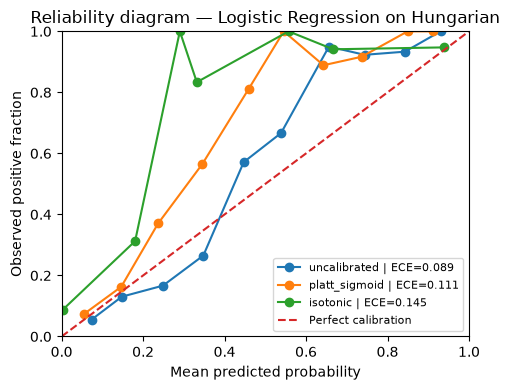

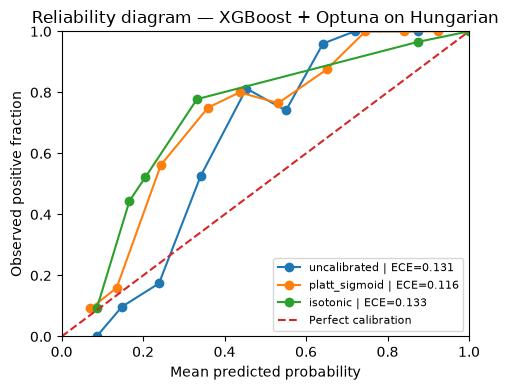

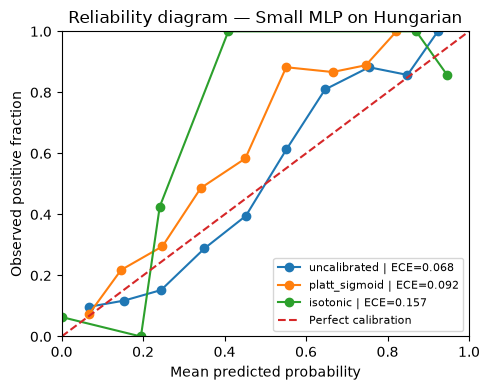

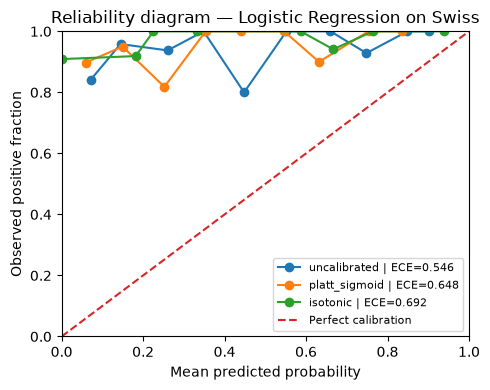

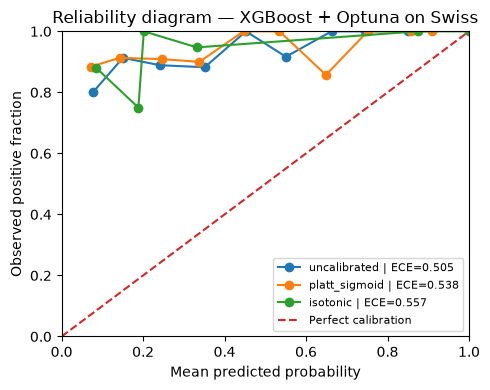

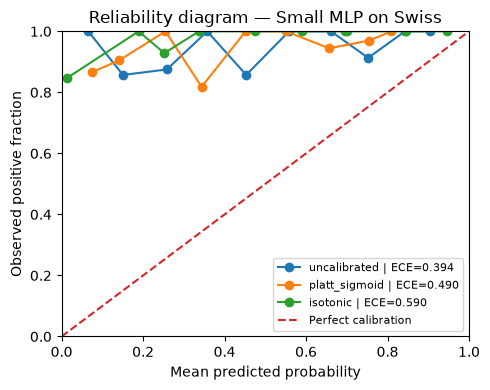

In [13]:
# Reliability diagrams for each model and external split.
for split_name, (X_ext, y_ext) in external_splits.items():
    for model_name in models:
        fig, ax = plt.subplots(figsize=(5, 4))
        for calibration_method in ["uncalibrated", "platt_sigmoid", "isotonic"]:
            model = calibrated_models[(model_name, calibration_method)]
            y_prob = get_positive_proba(model, X_ext)
            frac_pos, mean_pred = calibration_curve(y_ext, y_prob, n_bins=10, strategy="uniform")
            ece = expected_calibration_error(y_ext, y_prob, n_bins=10)
            ax.plot(mean_pred, frac_pos, marker="o", label=f"{calibration_method} | ECE={ece:.3f}")
        ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
        ax.set_title(f"Reliability diagram — {model_name} on {split_name}")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Observed positive fraction")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

## Domain adaptation ablation: no adaptation vs CORAL

This ablation uses the fitted Phase 3 preprocessing pipeline, then applies CORAL to map target-site processed features into Cleveland/source-space statistics before prediction.

This is unsupervised because it uses target features but not target labels for fitting the adapter. The labels are used only for evaluation after predictions are produced.

In [14]:
def predict_with_coral_target_to_source(model_pipeline, X_source_raw, X_target_raw):
    preprocess = model_pipeline.named_steps["preprocess"]
    model = model_pipeline.named_steps["model"]

    X_source_processed = preprocess.transform(X_source_raw)
    X_target_processed = preprocess.transform(X_target_raw)

    adapter = CORALTargetToSourceAdapter()
    adapter.fit(X_source_processed, X_target_processed)
    X_target_aligned = adapter.transform(X_target_processed)

    proba = model.predict_proba(X_target_aligned)
    return proba[:, 1]

adaptation_rows = []
for split_name, (X_ext, y_ext) in external_splits.items():
    for model_name, model in models.items():
        y_none = external_predictions[split_name][model_name]
        y_coral = predict_with_coral_target_to_source(model, X_cleveland, X_ext)

        metrics_none = compute_metrics(y_ext, y_none)
        metrics_coral = compute_metrics(y_ext, y_coral)

        adaptation_rows.append({"split": split_name, "model": model_name, "adaptation": "none", **metrics_none})
        adaptation_rows.append({"split": split_name, "model": model_name, "adaptation": "coral_target_to_source", **metrics_coral})

domain_adaptation_ablation = pd.DataFrame(adaptation_rows)

# Add delta columns relative to no adaptation.
delta_rows = []
for (split_name, model_name), group in domain_adaptation_ablation.groupby(["split", "model"]):
    none = group[group["adaptation"] == "none"].iloc[0]
    coral = group[group["adaptation"] == "coral_target_to_source"].iloc[0]
    row = {
        "split": split_name,
        "model": model_name,
        "auc_roc_delta": coral["auc_roc"] - none["auc_roc"],
        "auc_pr_delta": coral["auc_pr"] - none["auc_pr"],
        "f1_delta": coral["f1"] - none["f1"],
        "sensitivity_delta": coral["sensitivity"] - none["sensitivity"],
        "specificity_delta": coral["specificity"] - none["specificity"],
    }
    delta_rows.append(row)

domain_adaptation_delta = pd.DataFrame(delta_rows)

display(domain_adaptation_ablation.sort_values(["split", "model", "adaptation"]))
display(domain_adaptation_delta.sort_values(["split", "auc_roc_delta"], ascending=[True, False]))

,split,model,adaptation,auc_roc,auc_pr,f1,sensitivity,specificity,n,positive_rate
1,Hungarian,Logistic Regression,coral_target_to_source,0.869882,0.809963,0.766355,0.773585,0.861702,294,0.360544
0,Hungarian,Logistic Regression,none,0.857035,0.820928,0.681564,0.575472,0.936170,294,0.360544
5,Hungarian,Small MLP,coral_target_to_source,0.871939,0.816758,0.737778,0.783019,0.808511,294,0.360544
4,Hungarian,Small MLP,none,0.862605,0.813031,0.721649,0.660377,0.904255,294,0.360544
3,Hungarian,XGBoost + Optuna,coral_target_to_source,0.875853,0.793654,0.414286,0.273585,0.973404,294,0.360544
2,Hungarian,XGBoost + Optuna,none,0.886617,0.845701,0.621951,0.481132,0.962766,294,0.360544
7,Swiss,Logistic Regression,coral_target_to_source,0.642391,0.939440,0.677966,0.521739,0.750000,123,0.934959
6,Swiss,Logistic Regression,none,0.652174,0.957887,0.531646,0.365217,0.875000,123,0.934959
11,Swiss,Small MLP,coral_target_to_source,0.657609,0.942019,0.692737,0.539130,0.750000,123,0.934959
10,Swiss,Small MLP,none,0.704348,0.964569,0.728261,0.582609,0.750000,123,0.934959


,split,model,auc_roc_delta,auc_pr_delta,f1_delta,sensitivity_delta,specificity_delta
0,Hungarian,Logistic Regression,0.012846,-0.010965,0.084791,0.198113,-0.074468
1,Hungarian,Small MLP,0.009334,0.003727,0.016128,0.122642,-0.095745
2,Hungarian,XGBoost + Optuna,-0.010764,-0.052046,-0.207666,-0.207547,0.010638
3,Swiss,Logistic Regression,-0.009783,-0.018447,0.146321,0.156522,-0.125000
4,Swiss,Small MLP,-0.046739,-0.022550,-0.035523,-0.043478,0.000000
5,Swiss,XGBoost + Optuna,-0.123370,-0.017428,-0.369795,-0.304348,0.125000


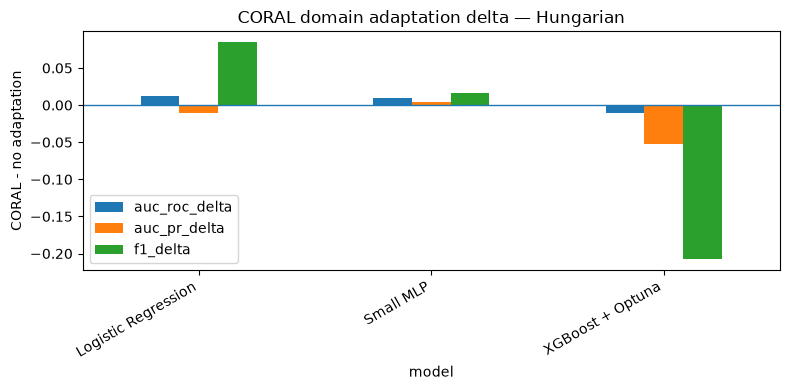

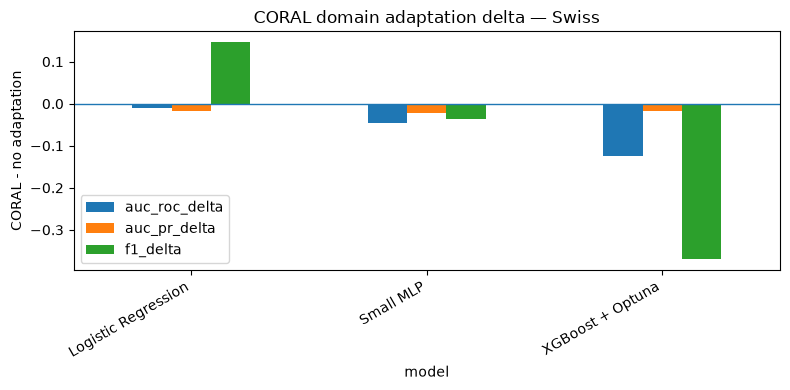

In [15]:
for split_name in external_splits:
    plot_df = domain_adaptation_delta[domain_adaptation_delta["split"] == split_name]
    ax = plot_df.set_index("model")[["auc_roc_delta", "auc_pr_delta", "f1_delta"]].plot(kind="bar", figsize=(8, 4))
    ax.axhline(0, linewidth=1)
    ax.set_title(f"CORAL domain adaptation delta — {split_name}")
    ax.set_ylabel("CORAL - no adaptation")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Explainability with SHAP

The required SHAP TreeExplainer analysis is applied to the optimized XGBoost model because TreeExplainer is designed for tree models. If another model is the best external model, the report can still discuss XGBoost SHAP as the tree-based explainability component and compare it with Logistic Regression coefficients or MLP performance.

The SHAP background and explained samples come from Cleveland after the Phase 3 preprocessing pipeline. This avoids using external test labels for explanation fitting.

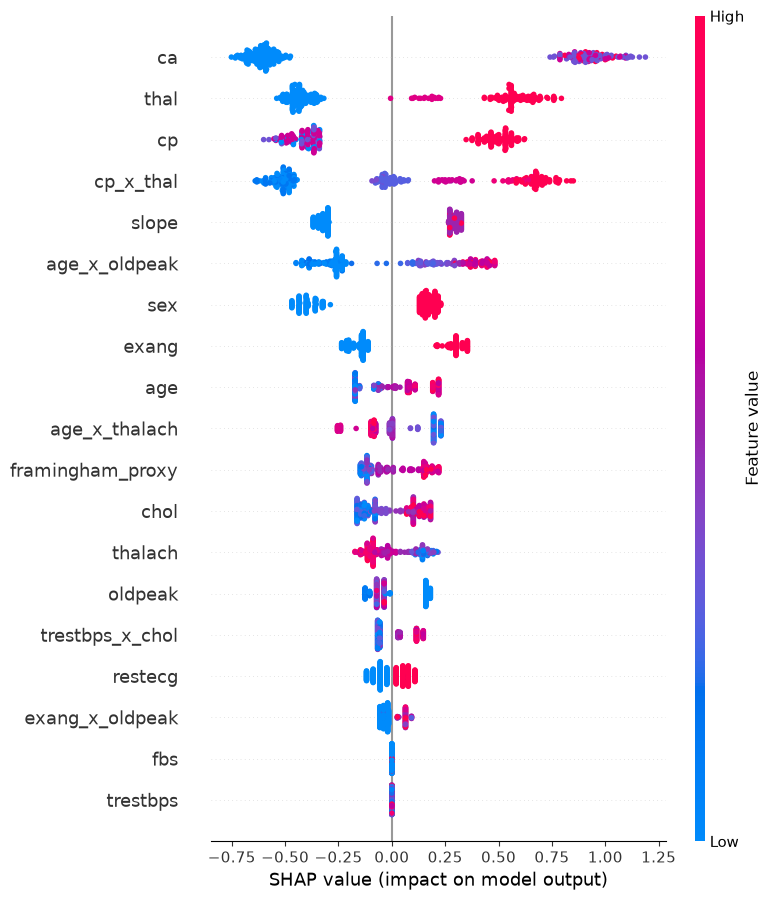

,feature,mean_abs_shap
11,ca,0.736365
12,thal,0.477379
2,cp,0.455107
16,cp_x_thal,0.438006
10,slope,0.308311
14,age_x_oldpeak,0.297915
1,sex,0.244532
8,exang,0.205265
0,age,0.126876
13,age_x_thalach,0.122316


In [16]:
if shap is None:
    print("Skipping SHAP because shap is not installed.")
else:
    xgb_pipeline = models["XGBoost + Optuna"]
    preprocess = xgb_pipeline.named_steps["preprocess"]
    xgb_model = xgb_pipeline.named_steps["model"]

    X_cleveland_processed = preprocess.transform(X_cleveland)
    feature_names = phase3_feature_names["feature"].tolist() if "feature" in phase3_feature_names.columns else [f"f{i}" for i in range(X_cleveland_processed.shape[1])]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_cleveland_processed)

    # For recent SHAP/XGBoost versions, shap_values may be a list for binary classification.
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_cleveland_processed, feature_names=feature_names, show=True)

    mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0)
    shap_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False)

    display(shap_importance.head(15))

## Final Phase 4 checklist

After running this notebook, collect these outputs for the final write-up and for the production `src/04_evaluation.py` runner:

- External performance table on Hungarian and Swiss.
- DeLong test result between the top two external models.
- Calibration summary with ECE before and after Platt/isotonic calibration.
- Reliability diagrams.
- CORAL domain adaptation ablation table and deltas.
- SHAP summary plot and top feature ranking.

Interpretation questions:

1. Does the best Cleveland CV model remain best on Hungarian and Swiss?
2. Does calibration improve ECE on external sites?
3. Does CORAL help or hurt each external split?
4. Do SHAP rankings make clinical sense, especially for features like chest pain type, thalassemia, max heart rate, ST depression, exercise angina, and age?

In [18]:
print("Phase 4 generated objects:")
print("external_performance:", external_performance.shape)
print("delong_results:", delong_results.shape)
print("calibration_summary:", calibration_summary.shape)
print("domain_adaptation_ablation:", domain_adaptation_ablation.shape)
print("domain_adaptation_delta:", domain_adaptation_delta.shape)

print("Best external models by split:")
display(external_performance.sort_values(["split", "auc_roc"], ascending=[True, False]).groupby("split").head(1))

Phase 4 generated objects:
external_performance: (6, 10)
delong_results: (2, 8)
calibration_summary: (18, 6)
domain_adaptation_ablation: (12, 10)
domain_adaptation_delta: (6, 7)
Best external models by split:


,split,model,adaptation,auc_roc,auc_pr,f1,sensitivity,specificity,n,positive_rate
1,Hungarian,XGBoost + Optuna,none,0.886617,0.845701,0.621951,0.481132,0.962766,294,0.360544
4,Swiss,XGBoost + Optuna,none,0.732065,0.974529,0.598802,0.434783,0.750000,123,0.934959
